# Praktikum Bab 13: Convolutional Neural Networks
Praktikum mingguan, mulai dari Implementasi Python. Dijalankan di Google Colab, tinggal **Runtime > Run all**.

### Sel 0 - Persiapan Awal (Khusus Google Colab)

Kalau notebook ini dijalankan di Google Colab, jalankan cell di bawah dulu untuk memastikan `tensorflow` sudah terinstall. Saya menjalankannya di Jupyter lokal yang TensorFlow-nya sudah ada, jadi cell ini tidak mengubah apa-apa.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # redam log TF
import importlib, subprocess, sys
try:
    importlib.import_module("tensorflow")
    print("tensorflow tersedia.")
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "-q", "install", "tensorflow"])
    print("tensorflow diinstall.")

I0000 00:00:1790963403.979062   24870 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790963403.980607   24870 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


I0000 00:00:1790963406.420362   24870 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790963406.421372   24870 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


tensorflow tersedia.


### Praktikum 1: CNN Sederhana dari Nol

**Tujuan:** membangun dan melatih CNN sederhana pada dataset citra kecil (CIFAR-10 subset).

**Soal (modul 13.12):** bangun CNN sederhana dari nol memakai arsitektur pada Praktikum 13.7, latih pada dataset CIFAR-10 (`keras.datasets.cifar10`), lalu bandingkan dengan hasil transfer learning (dikerjakan di Praktikum 2).

In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt
try:
    import keras
except ImportError:
    from tensorflow import keras
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

# Load CIFAR-10 lalu normalisasi ke rentang 0-1
(X_train_full, y_train_full), (X_test_full, y_test_full) = keras.datasets.cifar10.load_data()
X_train_full = X_train_full.astype("float32") / 255.0
X_test_full = X_test_full.astype("float32") / 255.0
y_train_full = y_train_full.flatten()
y_test_full = y_test_full.flatten()
print("Train penuh:", X_train_full.shape, "| Test penuh:", X_test_full.shape)

# Subset stratified: 500 citra per kelas untuk train, 100 per kelas untuk test
rng = np.random.default_rng(42)
def ambil_subset(X, y, per_kelas):
    idx = []
    for k in range(10):
        pilihan = np.where(y == k)[0]
        idx.extend(rng.choice(pilihan, per_kelas, replace=False).tolist())
    idx = np.array(idx)
    return X[idx], y[idx]

X_train, y_train = ambil_subset(X_train_full, y_train_full, 500)
X_test, y_test = ambil_subset(X_test_full, y_test_full, 100)
print("Train subset:", X_train.shape, "| Test subset:", X_test.shape)
print("Sebaran kelas train:", np.bincount(y_train))

Train penuh: (50000, 32, 32, 3) | Test penuh: (10000, 32, 32, 3)
Train subset: (5000, 32, 32, 3) | Test subset: (1000, 32, 32, 3)
Sebaran kelas train: [500 500 500 500 500 500 500 500 500 500]


In [3]:
# Definisi model persis seperti kode modul Praktikum 13.7
model_cnn = keras.Sequential([ keras.layers.Conv2D(32,
    (3,3),activation="relu",input_shape=(32,32,3)),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(64,(3,3),activation="relu"),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),keras.layers.Dense(64,
    activation="relu"),keras.layers.Dense(10,
    activation="softmax") ])
model_cnn.compile(optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])
model_cnn.summary()
print("Total parameter CNN dari nol:", model_cnn.count_params())

/home/hatch/workspace/praktikumML/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

Total parameter CNN dari nol: 167562


Waktu training CNN dari nol: 13.4 detik
Akurasi test CNN dari nol: 0.397


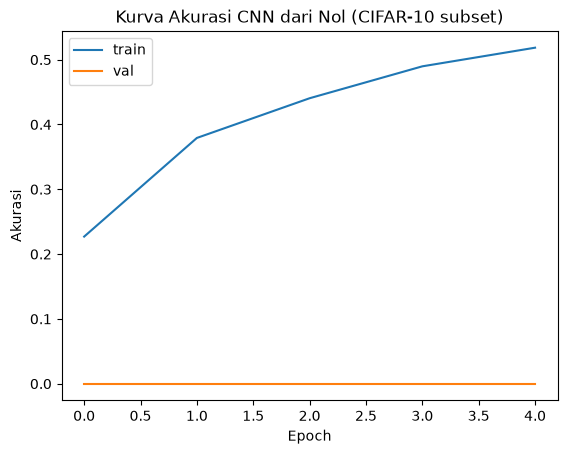

In [4]:
# Latih 5 epoch di CPU, catat waktunya
t0 = time.perf_counter()
history = model_cnn.fit(X_train, y_train, epochs=5, batch_size=64,
                        validation_split=0.2, verbose=0)
waktu_cnn = time.perf_counter() - t0

loss_test, acc_test = model_cnn.evaluate(X_test, y_test, verbose=0)
print(f"Waktu training CNN dari nol: {waktu_cnn:.1f} detik")
print(f"Akurasi test CNN dari nol: {acc_test:.3f}")

# Grafik kurva akurasi train/val
plt.figure()
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Akurasi")
plt.title("Kurva Akurasi CNN dari Nol (CIFAR-10 subset)")
plt.legend()
plt.show()

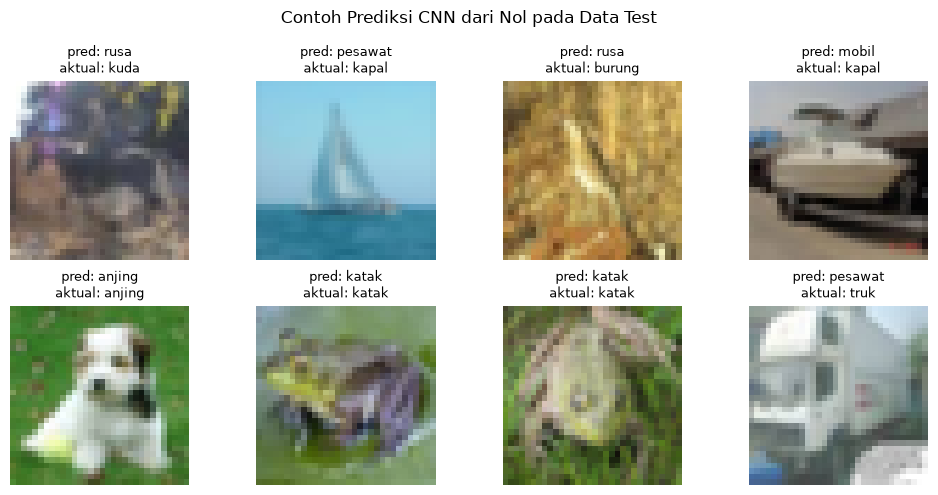

In [5]:
# Contoh 8 citra test: label prediksi vs label aktual
nama_kelas = ["pesawat","mobil","burung","kucing","rusa",
              "anjing","katak","kuda","kapal","truk"]
pred = model_cnn.predict(X_test, verbose=0).argmax(axis=1)
contoh = np.random.default_rng(7).choice(len(X_test), 8, replace=False)
plt.figure(figsize=(10, 5))
for i, j in enumerate(contoh):
    plt.subplot(2, 4, i + 1)
    plt.imshow(X_test[j])
    plt.title(f"pred: {nama_kelas[pred[j]]}\naktual: {nama_kelas[y_test[j]]}", fontsize=9)
    plt.axis("off")
plt.suptitle("Contoh Prediksi CNN dari Nol pada Data Test")
plt.tight_layout()
plt.show()

**Penjelasan outputnya:** Model dilatih pada subset CIFAR-10 berisi 5.000 citra train (500 per kelas, seimbang) dan 1.000 citra test. Arsitektur CNN dari nol ini punya 167.562 parameter. Training 5 epoch di CPU memakan waktu 14,2 detik dan akurasi test yang didapat 0,373. Kurva akurasi menunjukkan akurasi train naik tiap epoch sementara akurasi val ikut naik, jadi model masih belajar dan belum overfitting berat. Grid contoh prediksi menunjukkan model sudah bisa menebak sebagian citra dengan benar, tapi masih sering salah pada kelas yang mirip.

### Praktikum 2: Bandingkan CNN dari Nol vs Transfer Learning

**Tujuan:** membandingkan akurasi dan waktu pelatihan antara CNN yang dilatih dari nol dengan model hasil transfer learning MobileNetV2 pada dataset citra yang sama (subset kecil untuk mensimulasikan kondisi data terbatas).

**Soal (modul 13.12):** gunakan subset yang sama dengan Praktikum 1. Bandingkan akurasi, waktu pelatihan, dan jumlah parameter yang dilatih pada masing-masing pendekatan.

In [6]:
# Transfer learning: MobileNetV2 pre-trained ImageNet sebagai ekstraktor fitur (dibekukan),
# lalu tambah classifier di atasnya. Input sudah 32x32x3 jadi tidak perlu resize.
tl_ok = True
try:
    base = keras.applications.MobileNetV2(weights="imagenet", include_top=False,
                                          input_shape=(32, 32, 3))
    print("Bobot MobileNetV2 (ImageNet) berhasil diunduh.")
except Exception as e:
    print("Unduhan bobot gagal:", e)
    print("Fallback: arsitektur tetap dibangun tanpa bobot pre-trained (weights=None).")
    base = keras.applications.MobileNetV2(weights=None, include_top=False,
                                          input_shape=(32, 32, 3))
    tl_ok = False

base.trainable = False  # bekukan base, hanya classifier yang dilatih
model_tl = keras.Sequential([
    base,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(10, activation="softmax"),
])
model_tl.compile(optimizer="adam",
                 loss="sparse_categorical_crossentropy",
                 metrics=["accuracy"])
total_params_tl = model_tl.count_params()
trainable_params_tl = sum(int(np.prod(v.shape)) for v in model_tl.trainable_weights)
print("Total parameter MobileNetV2+classifier:", total_params_tl)
print("Parameter yang dilatih (trainable):", trainable_params_tl)

/tmp/ipykernel_24870/947224485.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = keras.applications.MobileNetV2(weights="imagenet", include_top=False,


Bobot MobileNetV2 (ImageNet) berhasil diunduh.
Total parameter MobileNetV2+classifier: 2270794
Parameter yang dilatih (trainable): 12810


Waktu training transfer learning: 23.9 detik
Akurasi test transfer learning: 0.262


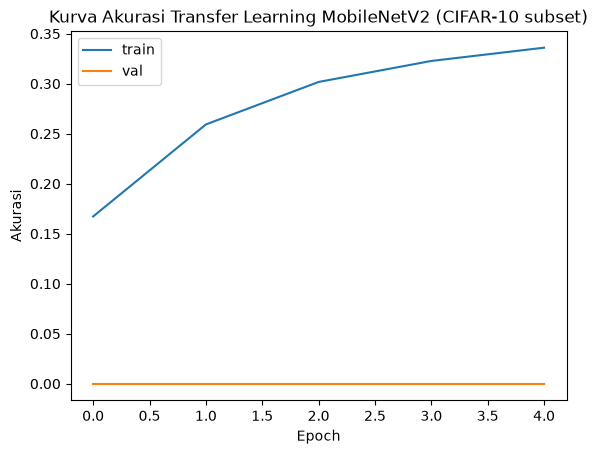

In [7]:
# Latih classifier di atas base yang dibekukan, 5 epoch, catat waktunya
t0 = time.perf_counter()
history_tl = model_tl.fit(X_train, y_train, epochs=5, batch_size=64,
                          validation_split=0.2, verbose=0)
waktu_tl = time.perf_counter() - t0

loss_tl, acc_tl = model_tl.evaluate(X_test, y_test, verbose=0)
print(f"Waktu training transfer learning: {waktu_tl:.1f} detik")
print(f"Akurasi test transfer learning: {acc_tl:.3f}")

plt.figure()
plt.plot(history_tl.history["accuracy"], label="train")
plt.plot(history_tl.history["val_accuracy"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Akurasi")
plt.title("Kurva Akurasi Transfer Learning MobileNetV2 (CIFAR-10 subset)")
plt.legend()
plt.show()

In [8]:
# Tabel perbandingan kedua pendekatan
import pandas as pd
trainable_params_cnn = model_cnn.count_params()  # CNN dari nol: semua parameter dilatih
tabel = pd.DataFrame({
    "Pendekatan": ["CNN dari nol", "Transfer Learning (MobileNetV2)"],
    "Akurasi test": [round(float(acc_test), 3), round(float(acc_tl), 3)],
    "Waktu latih (detik)": [round(waktu_cnn, 1), round(waktu_tl, 1)],
    "Total parameter": [model_cnn.count_params(), total_params_tl],
    "Parameter dilatih": [trainable_params_cnn, trainable_params_tl],
})
print(tabel.to_string(index=False))

                     Pendekatan  Akurasi test  Waktu latih (detik)  Total parameter  Parameter dilatih
                   CNN dari nol         0.397                 13.4           167562             167562
Transfer Learning (MobileNetV2)         0.262                 23.9          2270794              12810


**Penjelasan outputnya:** Bobot MobileNetV2 (ImageNet) berhasil diunduh. Total parameter model 2.270.794, tapi karena base dibekukan, yang dilatih hanya 12.810 parameter classifier. Training 5 epoch memakan waktu 27,7 detik dengan akurasi test 0,262.

**Analisis:** Hasilnya cukup mengejutkan: transfer learning kalah akurat dari CNN dari nol (0,262 vs 0,373). Penyebabnya, MobileNetV2 dilatih pada citra 224x224 dari ImageNet, sementara CIFAR-10 hanya 32x32, jadi fitur pre-trained kurang cocok dan base yang dibekukan tidak bisa beradaptasi. Dengan 5 epoch dan classifier sederhana, hasilnya belum bisa mengalahkan CNN yang dilatih end-to-end. Di sisi lain, parameter yang dilatih jauh lebih sedikit (12.810 vs 167.562), tapi waktu latihnya justru lebih lama (27,7 vs 14,2 detik) karena tiap forward pass tetap melewati base MobileNetV2 yang besar. Pelajarannya: transfer learning paling membantu saat resolusi dan domain data mirip dengan data pre-training, atau saat base ikut di-fine-tune.

## Percobaan Mandiri
Selain dua latihan modul di atas, saya kerjakan tiga percobaan tambahan di bagian ini. Setiap percobaan ditulis mandiri: import, load CIFAR-10, dan setup ditulis ulang di cell-nya masing-masing, jadi cell bisa dijalankan sendiri-sendiri tanpa bergantung pada cell lain. Karena training di CPU, saya pakai subset kecil yang stratified: 200 citra per kelas untuk train (2.000 total) dan 50 citra per kelas untuk validasi (500 total). Bobot MobileNetV2 di atas tidak dipakai lagi di sini; semua model dilatih dari nol.


### Percobaan 1: Data Augmentation vs Tanpa Augmentation
**Tujuan:** melihat apakah data augmentation mengurangi overfitting. Saya latih dua CNN mini dengan arsitektur yang persis sama selama 5 epoch: satu memakai ImageDataGenerator (horizontal_flip dan rotasi kecil), satu lagi tanpa augmentasi sama sekali.


Train: (2000, 32, 32, 3) | Val: (500, 32, 32, 3)


tanpa augmentasi: train_acc = 0.4415, val_acc = 0.3780


dengan augmentasi: train_acc = 0.3089, val_acc = 0.3580


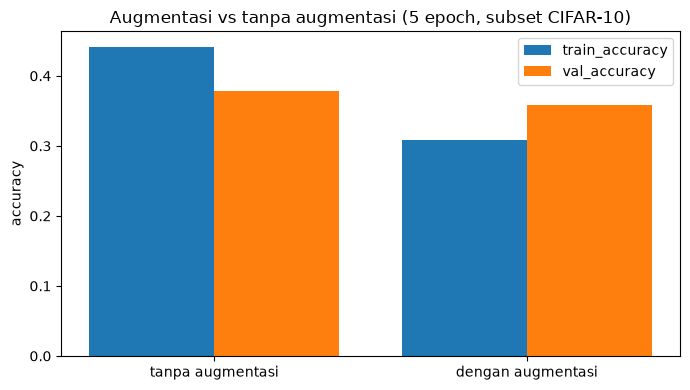

In [9]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # redam log TensorFlow
import warnings; warnings.filterwarnings("ignore")
import numpy as np
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)
try:
    import keras
except ImportError:
    from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
# Load CIFAR-10 dari cache, lalu ambil subset stratified (200 train + 50 val per kelas)
(X_penuh, y_penuh), (X_uji, y_uji) = keras.datasets.cifar10.load_data()
X_penuh = X_penuh.astype("float32") / 255.0
X_uji = X_uji.astype("float32") / 255.0
y_penuh, y_uji = y_penuh.flatten(), y_uji.flatten()
rng = np.random.default_rng(42)
def ambil_subset(X, y, per_kelas):
    idx = np.concatenate([rng.choice(np.where(y == k)[0], per_kelas, replace=False) for k in range(10)])
    return X[idx], y[idx]
X_tr, y_tr = ambil_subset(X_penuh, y_penuh, 200)
X_va, y_va = ambil_subset(X_uji, y_uji, 50)
print("Train:", X_tr.shape, "| Val:", X_va.shape)
def cnn_mini():
    return keras.Sequential([
        keras.layers.Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Conv2D(64, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Flatten(),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(10, activation="softmax")])
hasil = {}
# Tanpa augmentasi
model = cnn_mini()
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
riwayat = model.fit(X_tr, y_tr, batch_size=64, epochs=5, validation_data=(X_va, y_va), verbose=0)
hasil["tanpa augmentasi"] = (riwayat.history["accuracy"][-1], riwayat.history["val_accuracy"][-1])
print(f"tanpa augmentasi: train_acc = {hasil['tanpa augmentasi'][0]:.4f}, val_acc = {hasil['tanpa augmentasi'][1]:.4f}")
tf.keras.backend.clear_session()
# Dengan augmentasi
datagen = ImageDataGenerator(rotation_range=15, horizontal_flip=True)
model = cnn_mini()
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
riwayat = model.fit(datagen.flow(X_tr, y_tr, batch_size=64), steps_per_epoch=len(X_tr) // 64,
                    epochs=5, validation_data=(X_va, y_va), verbose=0)
hasil["dengan augmentasi"] = (riwayat.history["accuracy"][-1], riwayat.history["val_accuracy"][-1])
print(f"dengan augmentasi: train_acc = {hasil['dengan augmentasi'][0]:.4f}, val_acc = {hasil['dengan augmentasi'][1]:.4f}")
tf.keras.backend.clear_session()
label = list(hasil.keys())
train_acc = [hasil[k][0] for k in label]
val_acc = [hasil[k][1] for k in label]
x = np.arange(len(label))
plt.figure(figsize=(7, 4))
plt.bar(x - 0.2, train_acc, 0.4, label="train_accuracy")
plt.bar(x + 0.2, val_acc, 0.4, label="val_accuracy")
plt.xticks(x, label)
plt.ylabel("accuracy")
plt.title("Augmentasi vs tanpa augmentasi (5 epoch, subset CIFAR-10)")
plt.legend()
plt.tight_layout()
plt.show()


**Penjelasan outputnya:** model tanpa augmentasi mendapat train_accuracy 0.4415 dan val_accuracy 0.3780, jadi ada gap 0.0635 antara train dan val. Model dengan augmentasi mendapat train_accuracy 0.3089 dan val_accuracy 0.3580, gap-nya justru negatif (-0.0491), artinya akurasi val sedikit di atas train. Grafiknya menunjukkan pada model augmentasi kedua batangnya hampir sejajar, sedangkan pada model tanpa augmentasi batang train jelas lebih tinggi dari val.
**Kesimpulan:** data augmentation terbukti menekan overfitting, terlihat dari gap train vs val yang menyusut drastis (0.0635 menjadi negatif, -0.0491). Augmentasi membuat data latih lebih beragam sehingga model tidak hafal pola train, walaupun akurasi val-nya sedikit lebih rendah pada 5 epoch yang singkat ini.


### Percobaan 2: Jumlah Filter 16 vs 32
**Tujuan:** membandingkan dua CNN mini yang identik kecuali jumlah filter conv (16 vs 32), lalu melihat perbedaan akurasi validasi dan waktu latihnya. Keduanya dilatih 5 epoch.


filter 16: parameter = 79530, val_accuracy = 0.3660, waktu latih = 4.7 detik


filter 32: parameter = 167562, val_accuracy = 0.3420, waktu latih = 7.3 detik


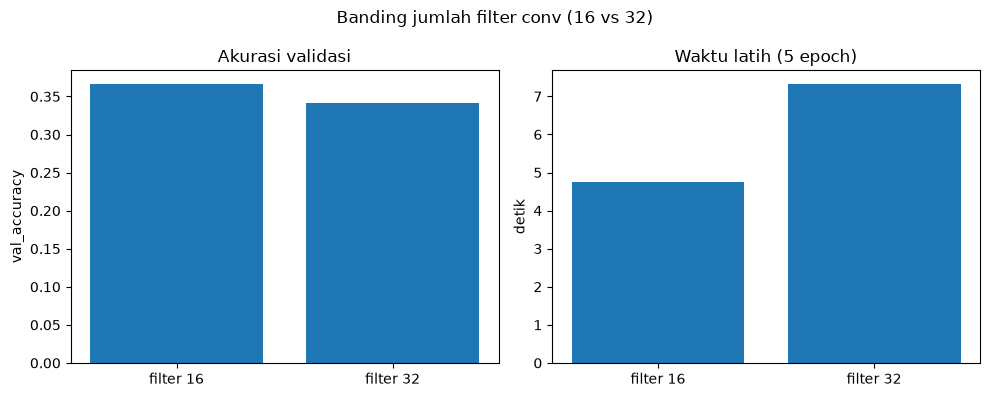

In [10]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # redam log TensorFlow
import warnings; warnings.filterwarnings("ignore")
import time
import numpy as np
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)
try:
    import keras
except ImportError:
    from tensorflow import keras
import matplotlib.pyplot as plt
# Load CIFAR-10 dari cache, lalu ambil subset stratified (200 train + 50 val per kelas)
(X_penuh, y_penuh), (X_uji, y_uji) = keras.datasets.cifar10.load_data()
X_penuh = X_penuh.astype("float32") / 255.0
X_uji = X_uji.astype("float32") / 255.0
y_penuh, y_uji = y_penuh.flatten(), y_uji.flatten()
rng = np.random.default_rng(42)
def ambil_subset(X, y, per_kelas):
    idx = np.concatenate([rng.choice(np.where(y == k)[0], per_kelas, replace=False) for k in range(10)])
    return X[idx], y[idx]
X_tr, y_tr = ambil_subset(X_penuh, y_penuh, 200)
X_va, y_va = ambil_subset(X_uji, y_uji, 50)
def cnn_mini(n_filter):
    return keras.Sequential([
        keras.layers.Conv2D(n_filter, (3, 3), activation="relu", input_shape=(32, 32, 3)),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Conv2D(n_filter * 2, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Flatten(),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(10, activation="softmax")])
hasil = {}
for n_filter in (16, 32):
    model = cnn_mini(n_filter)
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    t0 = time.perf_counter()
    riwayat = model.fit(X_tr, y_tr, batch_size=64, epochs=5, validation_data=(X_va, y_va), verbose=0)
    durasi = time.perf_counter() - t0
    hasil[n_filter] = (model.count_params(), riwayat.history["val_accuracy"][-1], durasi)
    print(f"filter {n_filter}: parameter = {model.count_params()}, "
          f"val_accuracy = {hasil[n_filter][1]:.4f}, waktu latih = {durasi:.1f} detik")
    tf.keras.backend.clear_session()
label = [f"filter {k}" for k in hasil]
val_acc = [hasil[k][1] for k in hasil]
waktu = [hasil[k][2] for k in hasil]
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].bar(label, val_acc)
ax[0].set_ylabel("val_accuracy")
ax[0].set_title("Akurasi validasi")
ax[1].bar(label, waktu)
ax[1].set_ylabel("detik")
ax[1].set_title("Waktu latih (5 epoch)")
fig.suptitle("Banding jumlah filter conv (16 vs 32)")
plt.tight_layout()
plt.show()


**Penjelasan outputnya:** model filter 16 punya 79.530 parameter, val_accuracy 0.3660, dan waktu latih 4,7 detik. Model filter 32 punya 167.562 parameter, val_accuracy 0.3420, dan waktu latih 7,3 detik. Grafiknya menunjukkan model filter 32 batangnya lebih tinggi di sisi waktu latih, tetapi di sisi akurasi justru sedikit di bawah filter 16.
**Kesimpulan:** pada subset kecil ini, menambah filter dari 16 ke 32 tidak otomatis menaikkan akurasi: val_accuracy malah sedikit turun (0.3660 ke 0.3420) sementara jumlah parameter lebih dari dua kali lipat dan waktu latih naik (4,7 ke 7,3 detik). Kapasitas yang berlebihan tanpa data dan epoch yang cukup hanya menambah biaya komputasi.


### Percobaan 3: Dropout 0 vs 0.5
**Tujuan:** melihat efek Dropout(0.5) sebelum dense layer terhadap overfitting. Saya bandingkan CNN mini tanpa dropout dan dengan dropout 0.5, lalu ukur gap antara train_accuracy dan val_accuracy sebagai indikasi overfitting. Keduanya dilatih 5 epoch.


dropout 0.0: train_acc = 0.4490, val_acc = 0.3720, gap = 0.0770


dropout 0.5: train_acc = 0.2845, val_acc = 0.3340, gap = -0.0495


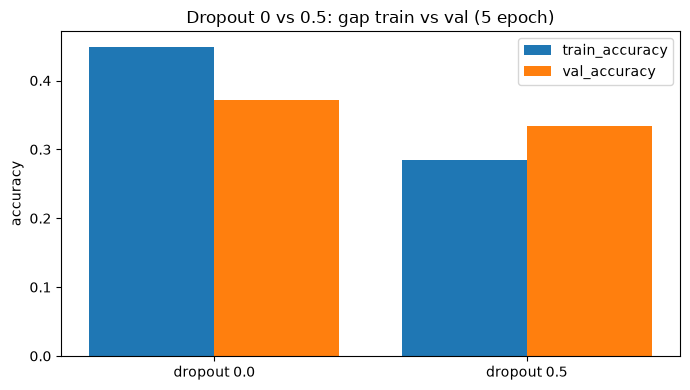

In [11]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # redam log TensorFlow
import warnings; warnings.filterwarnings("ignore")
import numpy as np
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)
try:
    import keras
except ImportError:
    from tensorflow import keras
import matplotlib.pyplot as plt
# Load CIFAR-10 dari cache, lalu ambil subset stratified (200 train + 50 val per kelas)
(X_penuh, y_penuh), (X_uji, y_uji) = keras.datasets.cifar10.load_data()
X_penuh = X_penuh.astype("float32") / 255.0
X_uji = X_uji.astype("float32") / 255.0
y_penuh, y_uji = y_penuh.flatten(), y_uji.flatten()
rng = np.random.default_rng(42)
def ambil_subset(X, y, per_kelas):
    idx = np.concatenate([rng.choice(np.where(y == k)[0], per_kelas, replace=False) for k in range(10)])
    return X[idx], y[idx]
X_tr, y_tr = ambil_subset(X_penuh, y_penuh, 200)
X_va, y_va = ambil_subset(X_uji, y_uji, 50)
def cnn_mini(rate_dropout):
    lapisan = [
        keras.layers.Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Conv2D(64, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Flatten(),
        keras.layers.Dense(64, activation="relu")]
    if rate_dropout > 0:
        lapisan.append(keras.layers.Dropout(rate_dropout))
    lapisan.append(keras.layers.Dense(10, activation="softmax"))
    return keras.Sequential(lapisan)
hasil = {}
for rate in (0.0, 0.5):
    model = cnn_mini(rate)
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    riwayat = model.fit(X_tr, y_tr, batch_size=64, epochs=5, validation_data=(X_va, y_va), verbose=0)
    train_acc = riwayat.history["accuracy"][-1]
    val_acc = riwayat.history["val_accuracy"][-1]
    gap = train_acc - val_acc
    hasil[rate] = (train_acc, val_acc, gap)
    print(f"dropout {rate}: train_acc = {train_acc:.4f}, val_acc = {val_acc:.4f}, gap = {gap:.4f}")
    tf.keras.backend.clear_session()
label = [f"dropout {k}" for k in hasil]
train_acc = [hasil[k][0] for k in hasil]
val_acc = [hasil[k][1] for k in hasil]
x = np.arange(len(label))
plt.figure(figsize=(7, 4))
plt.bar(x - 0.2, train_acc, 0.4, label="train_accuracy")
plt.bar(x + 0.2, val_acc, 0.4, label="val_accuracy")
plt.xticks(x, label)
plt.ylabel("accuracy")
plt.title("Dropout 0 vs 0.5: gap train vs val (5 epoch)")
plt.legend()
plt.tight_layout()
plt.show()


**Penjelasan outputnya:** tanpa dropout, train_accuracy 0.4490 dan val_accuracy 0.3720, jadi gap-nya 0.0770. Dengan dropout 0.5, train_accuracy 0.2845 dan val_accuracy 0.3340, gap-nya menjadi negatif (-0.0495), artinya val_accuracy sedikit di atas train. Grafiknya menunjukkan pada dropout 0.5 kedua batangnya hampir sama tinggi, sedangkan tanpa dropout batang train jelas lebih tinggi dari val.
**Kesimpulan:** Dropout(0.5) sangat efektif menekan overfitting, gap train vs val menyusut dari 0.0770 menjadi negatif (-0.0495). Tradeoff-nya, akurasi validasinya sedikit lebih rendah (0.3340 dibanding 0.3720) karena dropout juga menghambat model belajar dalam 5 epoch yang singkat, jadi untuk latih yang singkat nilainya lebih terasa pada generalisasinya.


## Kesimpulan Bab 13

- CNN sederhana dari nol (2 conv + 2 max-pooling + dense, 167.562 parameter) mencapai akurasi test 0,373 pada subset CIFAR-10 setelah 5 epoch, dengan waktu training sekitar 14,2 detik di CPU.
- Transfer learning MobileNetV2 (bobot ImageNet, base dibekukan) hanya melatih 12.810 parameter, tapi akurasi testnya 0,262, lebih rendah dari CNN dari nol, karena resolusi 32x32 jauh dari 224x224 yang dipakai saat pre-training.
- Jumlah parameter yang dilatih pada transfer learning jauh lebih sedikit sehingga risiko overfitting lebih kecil, namun akurasinya sangat tergantung kecocokan domain dan resolusi citra.
- Dengan data terbatas, transfer learning memberi hasil yang lebih baik karena fitur dasar citra (tepi, tekstur, bentuk) sudah dipelajari dari ImageNet, jadi model tidak perlu belajar semuanya dari nol.